# Système de recommandation agricole - Modélisation

## Librairies nécessaires

In [1]:
# Import de base
import pandas as pd
import numpy as np
import sys,os, joblib
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath(".."))

# Import scikit learn
from sklearn.model_selection import (train_test_split, KFold, cross_validate, GridSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# Import des autres modèles testés
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message=".*mlflow.sklearn.*")

# Import mlflow
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("file://" + os.path.abspath("../mlruns"))
from mlflow.tracking import MlflowClient
from mlflow.models.signature import infer_signature

# Import du projet
from scripts.preprocessing_pipeline import (
    separation_X_y,
    preparation_pipeline,
    cross_validation,
    train_predict
)

# Comparaison modèle sans optimisation sur le fichier consolidé

In [2]:
def mlflow_tracking_model(model, model_name, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Yield_Prediction_Agricultural")

    reg_name = "Yield_Forecaster_Global" 
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True)

    # =======================
    # Chargement des données
    df = pd.read_csv("../data/processed/yield_df_final_conso_encoded.csv", index_col=0)
    # Lancement du run
    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:
        # Split du train_test
        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # ==========================================
        # Pipeline & Cross-Validation
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )

        cv_results = cross_validation(pipeline=pipeline, X_train=X_train, y_train=y_train)
        
        # Calcul de la moyenne et de l'écart-type pour la CV
        cv_metrics = {
            "cv_rmse_mean": np.sqrt(-cv_results["test_mse"]).mean(),
            "cv_rmse_std": np.sqrt(-cv_results["test_mse"]).std(),
            "cv_mae_mean": (-cv_results["test_mae"]).mean(),
            "cv_mae_std": (-cv_results["test_mae"]).std(),
            "cv_mape_mean": (-cv_results["test_mape"]).mean(),
            "cv_mape_std": (-cv_results["test_mape"]).std(),
            "cv_r2_mean": cv_results["test_r2"].mean(),
            "cv_r2_std": cv_results["test_r2"].std()
        }
        # On log les métriques de la cv manuellement
        mlflow.log_metrics(cv_metrics)
        
        # Entraînement Final
        pipeline.fit(X_train, y_train)

        # ================================
        # Prédictions et métriques de test 
        y_pred = pipeline.predict(X_test)
        
        # ==========================================
        # CALCUL DE LA PRÉCISION ÉCONOMIQUE
        prices_fao = {
        "wheat": 260, "rice": 500, "maize": 210, "soybean": 520, "barley": 200,
        "potatoes": 250, "cassava": 140, "sorghum": 230, "yams": 750, "plantains": 450
    }
        # On crée un DataFrame temporaire pour le calcul
        results_df = pd.DataFrame({
            'actual': y_test,
            'pred': y_pred,
            'abs_error': np.abs(y_test - y_pred)
        }, index=X_test.index)

        # On récupère le nom de l'item depuis les colonnes dummies de X_test
        def get_crop_name(row_index):
            row = X_test.loc[row_index]
            for col in X_test.columns:
                if col.startswith('item_') and row[col] == 1:
                    return col.replace('item_', '')
            return "default"

        results_df['crop'] = [get_crop_name(idx) for idx in results_df.index]
        
        # Calcul du coût : (Erreur hg / 10 000) * prix FAO
        def calculate_monetary_error(row):
            price = prices_fao.get(row['crop'], 250) # 250$ par défaut
            return (row['abs_error'] / 10000) * price

        results_df['error_cost_usd_ha'] = results_df.apply(calculate_monetary_error, axis=1)
        
        # Métrique finale : coût moyen de l'erreur par hectare
        mean_economic_error = results_df['error_cost_usd_ha'].mean()

        test_metrics = {
            "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "test_mae": mean_absolute_error(y_test, y_pred),
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
            }
        mlflow.log_metrics(test_metrics)

        # =================================
        # Enregistrement et Model Registry
        signature = infer_signature(X_test, y_pred)
        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version
        
        # Description enrichie avec la notion de stabilité (std)
        full_description = (
            f"**Modèle :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV (Moyenne ± Écart-type) :**\n"
            f"- CV R2: {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})\n"
            f"- CV RMSE: {cv_metrics['cv_rmse_mean']:.2f} (± {cv_metrics['cv_rmse_std']:.2f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        
        # Tags pour comparaison rapide
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "CV_R2", round(cv_metrics["cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "CV_Std", round(cv_metrics["cv_r2_std"], 4))

        print(f"\n Version {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"CV RMSE   : {cv_metrics['cv_rmse_mean']:.4f}(± {cv_metrics['cv_rmse_std']:.2f})")
        print(f"CV MAE   : {cv_metrics['cv_mae_mean']:.4f}(±{cv_metrics['cv_mae_std']:.4f})")
        print(f"CV R2   : {cv_metrics['cv_r2_mean']:.4f}(± {cv_metrics['cv_r2_std']:.4f})")
        print(f"Test RMSE : {test_metrics['test_rmse']:.4f}")
        print(f"Test R2   : {test_metrics['test_r2']:.4f}")
        print(f"Test MAE   : {test_metrics['test_mae']:.4f}")
        print(f"Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n")


In [11]:
# DummyRegressor
model = DummyRegressor()
model_name = "DummyRegressor - Baseline"
tags = "DummyRegressor - Baseline"
projet_description = "Test d'un modèle DummyRegressor pour avoir une base sur laquelle comparer"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-03 11:12:14,916 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-03 11:12:14,916 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'is_drought_false', 'is_drought_true']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning:


 Version 1 enregistrée.

=== Résultats métriques ===
CV RMSE   : 75652.6639(± 1271.57)
CV MAE   : 55591.4405(±612.0935)
CV R2   : -0.0007(± 0.0003)
Test RMSE : 73864.1004
Test R2   : -0.0012
Test MAE   : 54567.1261
Test economic_error_usd_ha: 1610.3919

🏃 View run DummyRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/8dcb106bff824c2d873731ef65fe14fb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '1' of model 'Yield_Forecaster_Global'.


In [12]:
# Modèle de régression linéaire
model = LinearRegression()
model_name = "LinearRegression - Baseline"
tags = "LinearRegression - Baseline"
projet_description = "Test d'un modèle LinearRegression sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-03 11:12:32,947 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-03 11:12:32,948 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'is_drought_false', 'is_drought_true']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning:


 Version 2 enregistrée.

=== Résultats métriques ===
CV RMSE   : 48363.0503(± 1223.11)
CV MAE   : 32335.6167(±629.8350)
CV R2   : 0.5910(± 0.0130)
Test RMSE : 48105.9615
Test R2   : 0.5753
Test MAE   : 32112.6703
Test economic_error_usd_ha: 919.1522

🏃 View run LinearRegression - Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/19b10d0c410f4a15b06c449dd8c39dd3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '2' of model 'Yield_Forecaster_Global'.


In [13]:
# Modèle de RandomForest
model = RandomForestRegressor(random_state=42)
model_name = "RandomForest - Baseline"
tags = "RandomForest - Baseline"
projet_description = "Test d'un modèle Random Forest sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-03 11:12:40,018 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-03 11:12:40,018 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'is_drought_false', 'is_drought_true']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning:


 Version 3 enregistrée.

=== Résultats métriques ===
CV RMSE   : 18913.5200(± 1088.64)
CV MAE   : 8942.4472(±316.9905)
CV R2   : 0.9373(± 0.0064)
Test RMSE : 17976.6418
Test R2   : 0.9407
Test MAE   : 8232.4704
Test economic_error_usd_ha: 242.8092

🏃 View run RandomForest - Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/abfe3270f9b9450c9d58d3caf9960731
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '3' of model 'Yield_Forecaster_Global'.


In [14]:
# Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42)
model_name = "XGBRegressor - Baseline"
tags = "XGBRegressor - Baseline"
projet_description = "Test d'un modèle XGBRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-03 11:13:00,129 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-03 11:13:00,129 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'is_drought_false', 'is_drought_true']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning:


 Version 4 enregistrée.

=== Résultats métriques ===
CV RMSE   : 21495.8051(± 920.53)
CV MAE   : 12874.5980(±315.0375)
CV R2   : 0.9191(± 0.0064)
Test RMSE : 20327.0342
Test R2   : 0.9242
Test MAE   : 12291.3828
Test economic_error_usd_ha: 361.4870

🏃 View run XGBRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/2f911b69ed024733af09b00f02d24f93
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '4' of model 'Yield_Forecaster_Global'.


In [15]:
# Modèle de LightGBM
model = lgb.LGBMRegressor(random_state=42, verbose=-1)
model_name = "LGBMRegressor - Baseline"
tags = "LGBMRegressor - Baseline"
projet_description = "Test d'un modèle LGBMRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-03 11:13:07,106 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-03 11:13:07,106 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'is_drought_false', 'is_drought_true']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning:


 Version 5 enregistrée.

=== Résultats métriques ===
CV RMSE   : 26821.1310(± 808.12)
CV MAE   : 17004.2440(±290.6210)
CV R2   : 0.8741(± 0.0067)
Test RMSE : 26426.8433
Test R2   : 0.8718
Test MAE   : 16609.2336
Test economic_error_usd_ha: 483.5805

🏃 View run LGBMRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/1/runs/87210112bbf54ed5b0a237d09297c3c6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '5' of model 'Yield_Forecaster_Global'.


- Sur ces premiers tests, le modèle qui s'en sort le mieux sur l'ensemble des métriques (performance et métier) c'est celui de Random Forest.
- Les résultats de XGBoost et LightGBM sont exploitables pour essayer d'améliorer leur performance.
- Par contre le modèle de régression linéaire est trop loin en terme de performance. Au vu de la distribution de notre varibale cible, cela n'est pas étonnant.

# Comparaison modèle sans optimisation sur le fichier enrichi

In [16]:
def mlflow_tracking_model(model, model_name, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Yield_Prediction_Agricultural")

    reg_name = "Yield_Forecaster_Global" 
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True)

    # =======================
    # Chargement des données
    df = pd.read_csv("../data/processed/yield_df_enriched_encoded.csv", index_col=0)
    # Lancement du run
    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:
        # Split du train_test
        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # ==========================================
        # Pipeline & Cross-Validation
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )

        cv_results = cross_validation(pipeline=pipeline, X_train=X_train, y_train=y_train)
        
        # Calcul de la moyenne et de l'écart-type pour la CV
        cv_metrics = {
            "cv_rmse_mean": np.sqrt(-cv_results["test_mse"]).mean(),
            "cv_rmse_std": np.sqrt(-cv_results["test_mse"]).std(),
            "cv_mae_mean": (-cv_results["test_mae"]).mean(),
            "cv_mae_std": (-cv_results["test_mae"]).std(),
            "cv_mape_mean": (-cv_results["test_mape"]).mean(),
            "cv_mape_std": (-cv_results["test_mape"]).std(),
            "cv_r2_mean": cv_results["test_r2"].mean(),
            "cv_r2_std": cv_results["test_r2"].std()
        }
        # On log les métriques de la cv manuellement
        mlflow.log_metrics(cv_metrics)
        
        # Entraînement Final
        pipeline.fit(X_train, y_train)

        # ================================
        # Prédictions et métriques de test 
        y_pred = pipeline.predict(X_test)
        
        # ==========================================
        # CALCUL DE LA PRÉCISION ÉCONOMIQUE
        prices_fao = {
        "wheat": 260, "rice": 500, "maize": 210, "soybean": 520, "barley": 200,
        "potatoes": 250, "cassava": 140, "sorghum": 230, "yams": 750, "plantains": 450
    }
        # On crée un DataFrame temporaire pour le calcul
        results_df = pd.DataFrame({
            'actual': y_test,
            'pred': y_pred,
            'abs_error': np.abs(y_test - y_pred)
        }, index=X_test.index)

        # On récupère le nom de l'item depuis les colonnes dummies de X_test
        def get_crop_name(row_index):
            row = X_test.loc[row_index]
            for col in X_test.columns:
                if col.startswith('item_') and row[col] == 1:
                    return col.replace('item_', '')
            return "default"

        results_df['crop'] = [get_crop_name(idx) for idx in results_df.index]
        
        # Calcul du coût : (Erreur hg / 10 000) * prix FAO
        def calculate_monetary_error(row):
            price = prices_fao.get(row['crop'], 250) # 250$ par défaut
            return (row['abs_error'] / 10000) * price

        results_df['error_cost_usd_ha'] = results_df.apply(calculate_monetary_error, axis=1)
        
        # Métrique finale : coût moyen de l'erreur par hectare
        mean_economic_error = results_df['error_cost_usd_ha'].mean()

        test_metrics = {
            "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "test_mae": mean_absolute_error(y_test, y_pred),
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
            }
        mlflow.log_metrics(test_metrics)

        # =================================
        # Enregistrement et Model Registry
        signature = infer_signature(X_test, y_pred)
        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version
        
        # Description enrichie avec la notion de stabilité (std)
        full_description = (
            f"**Modèle :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV (Moyenne ± Écart-type) :**\n"
            f"- CV R2: {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})\n"
            f"- CV RMSE: {cv_metrics['cv_rmse_mean']:.2f} (± {cv_metrics['cv_rmse_std']:.2f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        
        # Tags pour comparaison rapide
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "CV_R2", round(cv_metrics["cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "CV_Std", round(cv_metrics["cv_r2_std"], 4))

        print(f"\n Version {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"CV RMSE   : {cv_metrics['cv_rmse_mean']:.4f}(± {cv_metrics['cv_rmse_std']:.2f})")
        print(f"CV MAE   : {cv_metrics['cv_mae_mean']:.4f}(±{cv_metrics['cv_mae_std']:.4f})")
        print(f"CV R2   : {cv_metrics['cv_r2_mean']:.4f}(± {cv_metrics['cv_r2_std']:.4f})")
        print(f"Test RMSE : {test_metrics['test_rmse']:.4f}")
        print(f"Test R2   : {test_metrics['test_r2']:.4f}")
        print(f"Test MAE   : {test_metrics['test_mae']:.4f}")
        print(f"Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n")


In [17]:
# DummyRegressor
model = DummyRegressor()
model_name = "DummyRegressor - Baseline - fichier enrichi"
tags = "DummyRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle DummyRegressor pour avoir une base sur laquelle comparer"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-03 11:15:48,712 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'irrigation_impact', 'climate_instability', 'relative_tech_intensity']
2026-04-03 11:15:48,712 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'fertilizer_used_false', 'fertilizer_used_true', 'irrigation_used_false', 'irrigation_used_true', 'weather_condition_cloudy', 'weather_condition_rainy', 'weather_condition_sunny', 'so


 Version 6 enregistrée.

=== Résultats métriques ===
CV RMSE   : 75652.6639(± 1271.57)
CV MAE   : 55591.4405(±612.0935)
CV R2   : -0.0007(± 0.0003)
Test RMSE : 73864.1004
Test R2   : -0.0012
Test MAE   : 54567.1261
Test economic_error_usd_ha: 1610.3919

🏃 View run DummyRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/1/runs/3edec6a6d18e45048d61780783f74399
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '6' of model 'Yield_Forecaster_Global'.


In [18]:
# Modèle de régression linéaire
model = LinearRegression()
model_name = "LinearRegression - Baseline - fichier enrichi"
tags = "LinearRegression - Baseline - fichier enrichi"
projet_description = "Test d'un modèle LinearRegression sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-03 11:15:53,777 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'irrigation_impact', 'climate_instability', 'relative_tech_intensity']
2026-04-03 11:15:53,777 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'fertilizer_used_false', 'fertilizer_used_true', 'irrigation_used_false', 'irrigation_used_true', 'weather_condition_cloudy', 'weather_condition_rainy', 'weather_condition_sunny', 'so


 Version 7 enregistrée.

=== Résultats métriques ===
CV RMSE   : 48458.7554(± 1195.87)
CV MAE   : 32385.9859(±606.1592)
CV R2   : 0.5894(± 0.0122)
Test RMSE : 48168.1604
Test R2   : 0.5742
Test MAE   : 32134.6345
Test economic_error_usd_ha: 918.7341

🏃 View run LinearRegression - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/1/runs/18b15a90a8e44c24b31216806f0db9e1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '7' of model 'Yield_Forecaster_Global'.


In [19]:
# Modèle de RandomForest
model = RandomForestRegressor(random_state=42)
model_name = "RandomForest - Baseline - fichier enrichi"
tags = "RandomForest - Baseline"
projet_description = "Test d'un modèle Random Forest sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-03 11:15:58,454 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'irrigation_impact', 'climate_instability', 'relative_tech_intensity']
2026-04-03 11:15:58,454 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'fertilizer_used_false', 'fertilizer_used_true', 'irrigation_used_false', 'irrigation_used_true', 'weather_condition_cloudy', 'weather_condition_rainy', 'weather_condition_sunny', 'so


 Version 8 enregistrée.

=== Résultats métriques ===
CV RMSE   : 18502.7297(± 1083.85)
CV MAE   : 9128.6996(±351.2340)
CV R2   : 0.9400(± 0.0064)
Test RMSE : 17638.6699
Test R2   : 0.9429
Test MAE   : 8281.8119
Test economic_error_usd_ha: 246.4683

🏃 View run RandomForest - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/1/runs/72ab58c0658a41d68354e7977b1cab8e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '8' of model 'Yield_Forecaster_Global'.


In [20]:
# Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42)
model_name = "XGBRegressor - Baseline - fichier enrichi"
tags = "XGBRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle XGBRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-03 11:16:21,209 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'irrigation_impact', 'climate_instability', 'relative_tech_intensity']
2026-04-03 11:16:21,210 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'fertilizer_used_false', 'fertilizer_used_true', 'irrigation_used_false', 'irrigation_used_true', 'weather_condition_cloudy', 'weather_condition_rainy', 'weather_condition_sunny', 'so


 Version 9 enregistrée.

=== Résultats métriques ===
CV RMSE   : 21594.2248(± 1032.84)
CV MAE   : 13005.7313(±264.1568)
CV R2   : 0.9183(± 0.0072)
Test RMSE : 20784.7675
Test R2   : 0.9207
Test MAE   : 12253.4619
Test economic_error_usd_ha: 363.5193

🏃 View run XGBRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/1/runs/d4590312d56a4f198396b942301bb1fe
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '9' of model 'Yield_Forecaster_Global'.


In [21]:
# Modèle de LightGBM
model = lgb.LGBMRegressor(random_state=42, verbose=-1)
model_name = "LGBMRegressor - Baseline - fichier enrichi"
tags = "LGBMRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle LGBMRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-03 11:16:26,203 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'tech_trend', 'irrigation_impact', 'climate_instability', 'relative_tech_intensity']
2026-04-03 11:16:26,204 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'fertilizer_used_false', 'fertilizer_used_true', 'irrigation_used_false', 'irrigation_used_true', 'weather_condition_cloudy', 'weather_condition_rainy', 'weather_condition_sunny', 'so


 Version 10 enregistrée.

=== Résultats métriques ===
CV RMSE   : 26499.9431(± 671.19)
CV MAE   : 16859.2149(±259.1014)
CV R2   : 0.8771(± 0.0057)
Test RMSE : 25907.2720
Test R2   : 0.8768
Test MAE   : 16328.3666
Test economic_error_usd_ha: 477.6410

🏃 View run LGBMRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/1/runs/cb314c6614f245f8aa55109321a20d15
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '10' of model 'Yield_Forecaster_Global'.


# Optimisation des hyperparamètres sur RandomForest / XGBoost & LightGBM

A l'aide de gridsearchCV, on va essayer ici de trouver les meilleurs hyperparamètres pour chacun des modèles

In [5]:
def mlflow_tracking_gridsearch(model, model_name, param_grid, tags, projet_description):
    # ==========================================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Yield_Prediction_Agricultural")
    reg_name = "Yield_Forecaster_GridSearch"
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True, max_tuning_runs=0)

    df = pd.read_csv("../data/processed/yield_df_final_conso_encoded.csv", index_col=0)

    with mlflow.start_run(run_name=f"{model_name}") as run:
        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)
        pipeline = preparation_pipeline(numeric_cols, categorical_cols, model)
        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        mlflow.set_tag("model_family", "RandomForest")
        mlflow.set_tag("optimization_metric", "MAE")
        mlflow.set_tag("search_type", "GridSearchCV")
        mlflow.set_tag("project", "Yield_Prediction_Agricultural")
        mlflow.set_tag("dataset_version", "yield_df_final_conso_encoded")
        mlflow.set_tag("run_purpose", "hyperparameter_tuning")
        
        # On utilise GridSearchCV
        grid_search = GridSearchCV(
            estimator=pipeline, 
            param_grid=param_grid, 
            scoring='r2', 
            n_jobs=-1, 
            cv=cv,
            refit=True,
            error_score='raise'
        )
        grid_search.fit(X_train, y_train)
        
        # --- Récupération des meilleurs stats de la cv---
        best_index = grid_search.best_index_
        # Le MAE moyen et son écart-type
        cv_r2_mean = grid_search.best_score_
        cv_r2_std = grid_search.cv_results_['std_test_score'][best_index]

        mlflow.log_params(grid_search.best_params_)
        mlflow.log_metrics({
            "best_cv_mae_mean": cv_r2_mean,
            "best_cv_mae_std": cv_r2_std
        })

        # --- ÉVALUATION SUR TEST AVEC LE MEILLEUR PIPELINE ---
        best_pipeline = grid_search.best_estimator_
        y_pred = best_pipeline.predict(X_test)
      
       # ==========================================
        # CALCUL DE LA PRÉCISION ÉCONOMIQUE
        prices_fao = {
        "wheat": 260, "rice": 500, "maize": 210, "soybean": 520, "barley": 200,
        "potatoes": 250, "cassava": 140, "sorghum": 230, "yams": 750, "plantains": 450
    }
        # On crée un DataFrame temporaire pour le calcul
        results_df = pd.DataFrame({
            'actual': y_test,
            'pred': y_pred,
            'abs_error': np.abs(y_test - y_pred)
        }, index=X_test.index)

        # On récupère le nom de l'item depuis les colonnes dummies de X_test
        def get_crop_name(row_index):
            row = X_test.loc[row_index]
            for col in X_test.columns:
                if col.startswith('item_') and row[col] == 1:
                    return col.replace('item_', '')
            return "default"

        results_df['crop'] = [get_crop_name(idx) for idx in results_df.index]
        
        # Calcul du coût : (Erreur hg / 10 000) * prix FAO
        def calculate_monetary_error(row):
            price = prices_fao.get(row['crop'], 250) # 250$ par défaut
            return (row['abs_error'] / 10000) * price

        results_df['error_cost_usd_ha'] = results_df.apply(calculate_monetary_error, axis=1)
        
        # Métrique finale : coût moyen de l'erreur par hectare
        mean_economic_error = results_df['error_cost_usd_ha'].mean()

        test_metrics = {
            "test_rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "test_mae": mean_absolute_error(y_test, y_pred),
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
        }
        mlflow.log_metrics(test_metrics)

        # ==========================================
        # Registre les modèles avec détails complets
        signature = infer_signature(X_test, y_pred)
        joblib.dump(best_pipeline, "../model/yield_pipeline_test.joblib")
        joblib.dump(X_train.columns.tolist(), "../model/feature_columns_test.joblib")
        model_info = mlflow.sklearn.log_model(
            sk_model=best_pipeline, 
            name="model", 
            signature=signature, 
            registered_model_name=reg_name
        )
        
        client = MlflowClient()
        mv = model_info.registered_model_version
        
        full_description = (
            f"**Modèle Optimisé :** {model_name}\n"
            f"**Méthode :** GridSearchCV\n\n"
            f"**Performance CV (Best Params) :**\n"
            f"- R2: {cv_r2_mean:.4f} (± {cv_r2_std:.4f})\n\n"
            f"**Performance Test Final :**\n"
            f"- R2: {test_metrics['test_r2']:.4f}\n"
            f"- MAE Test: {test_metrics['test_mae']:.2f}\n"
            f"- RMSE Test: {test_metrics['test_rmse']:.2f}\n"
            f"- MAPE Test: {test_metrics['test_mape']:.2%}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
            )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        
        # Tags de comparaison
        client.set_model_version_tag(reg_name, mv, "Status", "Optimized")
        client.set_model_version_tag(reg_name, mv, "Test_MAE", round(test_metrics["test_mae"], 2))
        client.set_model_version_tag(reg_name, mv, "Test_R2", round(test_metrics["test_r2"], 4))
        client.set_model_version_tag(reg_name, mv, "Test_RMSE", round(test_metrics["test_rmse"], 2))
        client.set_model_version_tag(reg_name, mv, "Test_MAPE", round(test_metrics["test_mape"], 4))

        print(f"GridSearch Version {mv} enregistrée.")

        print(f"\n GridSearch Version {mv} terminée pour {model_name}")
        print(f"---")
        print(f"Meilleur R2 en CV : {cv_r2_mean:.4f} (± {cv_r2_std:.4f})")
        print(f"R2 sur le Test Set : {test_metrics['test_r2']:.4f}")
        print(f"Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n")
        print(f"---")
        print(f"MEILLEURS PARAMÈTRES TROUVÉS :")
        for param, value in grid_search.best_params_.items():
            print(f"  - {param}: {value}")
        print(f"---")

        return {
            "best_pipeline": best_pipeline,
            "best_params": grid_search.best_params_,
            "test_metrics": test_metrics
            }

In [6]:
 # Modèle de RandomForest
model = RandomForestRegressor(random_state=42, n_jobs=1)
model_name = "RandomForest - GridSearchCV"
param_grid = {
    'model__n_estimators': [1000, 1200],
    'model__max_depth': [25], # Profondeur des arbres
    'model__min_samples_split': [3, 4], # Nombre minimum d'échantillon dans une feuille
    'model__min_samples_leaf': [1],
    'model__max_features': [0.7], # Nombre de focntionnalités à prendre en compte
    'model__bootstrap': [True] # Réalise des échantillons
    }
tags = "RandomForest - GridSearchCV"
projet_description = "L'objectif est de trouver les meilleurs paramètres possibles pour ce modèle"
mlflow_tracking_gridsearch(model, model_name,param_grid, tags, projet_description)

2026-04-03 14:17:45,589 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-03 14:17:45,590 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'is_drought_false', 'is_drought_true']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning:

GridSearch Version 3 enregistrée.

 GridSearch Version 3 terminée pour RandomForest - GridSearchCV
---
Meilleur R2 en CV : 0.9390 (± 0.0060)
R2 sur le Test Set : 0.9415
Test economic_error_usd_ha: 243.2869

---
MEILLEURS PARAMÈTRES TROUVÉS :
  - model__bootstrap: True
  - model__max_depth: 25
  - model__max_features: 0.7
  - model__min_samples_leaf: 1
  - model__min_samples_split: 3
  - model__n_estimators: 1000
---
🏃 View run RandomForest - GridSearchCV at: http://127.0.0.1:5000/#/experiments/1/runs/3dc044d1ff0d469d82203112cfdd5391
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '3' of model 'Yield_Forecaster_GridSearch'.


{'best_pipeline': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['avg_temp', 'rainfall_mm',
                                                    'pesticides_tonnes',
                                                    'input_imbalance',
                                                    'thermal_stress',
                                                    'years_from_now']),
                                                  ('cat', 'passthrough',
                                                   ['region_australia_and_new_zealand',
                                                    'region_central_asia',
                                                    'region_eastern_asia',
                                                    'region_eastern_europe',
                                                    'region_latin_america_and_the_caribbe...
                           

In [31]:
 # Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42, n_jobs=-1)
model_name = "XGBRegressor - GridSearchCV"
param_grid = {
    'model__n_estimators': [200],
    'model__max_depth': [6, 8, 10],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bynode': [0.8, 0.9],
    'model__min_child_weight': [1, 3]
}
tags = "XGBRFRegressor - GridSearchCV"
projet_description = "L'objectif est de trouver les meilleurs paramètres possibles pour ce modèle"
mlflow_tracking_gridsearch(model, model_name,param_grid, tags, projet_description)

2026-04-03 11:29:19,967 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-03 11:29:19,968 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'is_drought_false', 'is_drought_true']
/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning:

GridSearch Version 1 enregistrée.

 GridSearch Version 1 terminée pour XGBRegressor - GridSearchCV
---
Meilleur R2 en CV : 0.9393 (± 0.0058)
R2 sur le Test Set : 0.9405
Test economic_error_usd_ha: 266.2326

---
MEILLEURS PARAMÈTRES TROUVÉS :
  - model__colsample_bynode: 0.9
  - model__max_depth: 10
  - model__min_child_weight: 3
  - model__n_estimators: 200
  - model__subsample: 1.0
---
🏃 View run XGBRegressor - GridSearchCV at: http://127.0.0.1:5000/#/experiments/1/runs/75cf2024e69145bb9d2e8a1971dc1b67
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Created version '1' of model 'Yield_Forecaster_GridSearch'.


{'best_pipeline': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['avg_temp', 'rainfall_mm',
                                                    'pesticides_tonnes',
                                                    'input_imbalance',
                                                    'thermal_stress',
                                                    'years_from_now']),
                                                  ('cat', 'passthrough',
                                                   ['region_australia_and_new_zealand',
                                                    'region_central_asia',
                                                    'region_eastern_asia',
                                                    'region_eastern_europe',
                                                    'region_latin_america_and_the_caribbe...
                           

# Feature importance


Top 15 features :
                                  feature  importance
0                      cat__item_potatoes    0.310736
1                  num__pesticides_tonnes    0.093907
2                        num__rainfall_mm    0.087052
3              cat__region_western_europe    0.049262
4                    num__input_imbalance    0.048940
5                cat__item_sweet_potatoes    0.043896
6                       cat__item_cassava    0.043189
7                     num__years_from_now    0.038476
8                           num__avg_temp    0.038366
9                     num__thermal_stress    0.032514
10         cat__region_sub-saharan_africa    0.027381
11         cat__item_plantains_and_others    0.024460
12                         cat__item_yams    0.021879
13                      cat__item_soybean    0.014192
14  cat__region_australia_and_new_zealand    0.014041


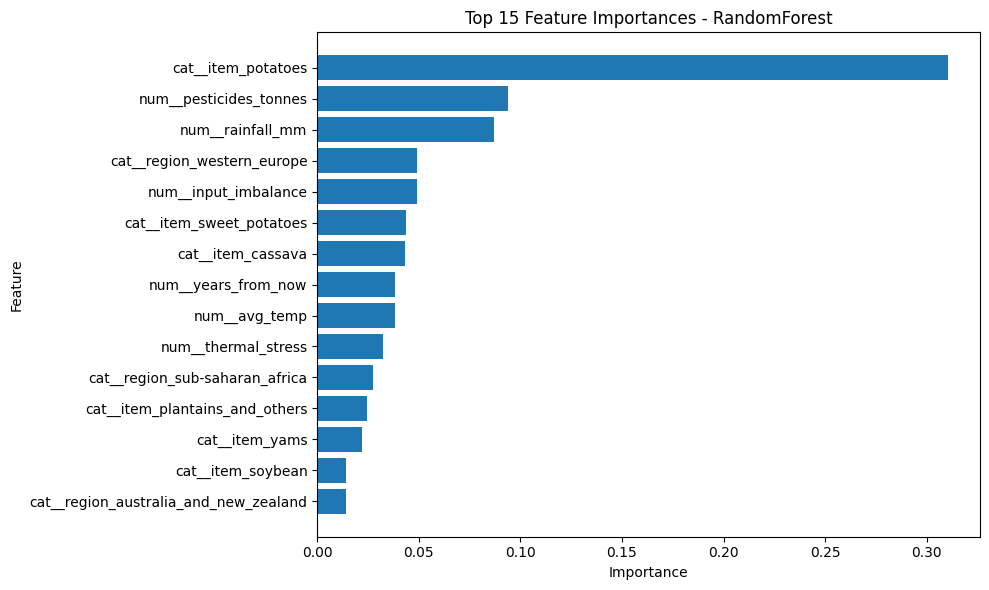


Importance par groupe :
                  group  importance
0                  item    0.489387
1  numeric_climate_tech    0.300780
2                region    0.168587
3                 other    0.041247


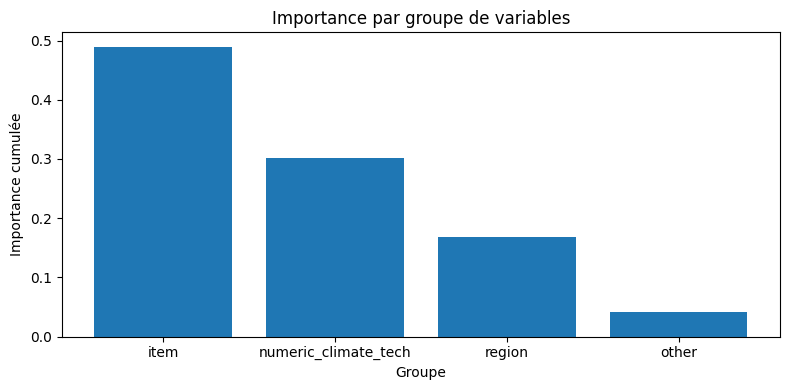

In [38]:

best_pipeline = joblib.load("../model/yield_pipeline.joblib")
# Extraire le modèle et le préprocesseur du pipeline
rf_model = best_pipeline.named_steps["model"]
preprocessor = best_pipeline.named_steps["preprocessor"]

# Récupérer les noms de variables après transformation
feature_names = preprocessor.get_feature_names_out()

# Récupérer les importances
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nTop 15 features :")
print(feature_importance_df.head(15))

# Sauvegarder les importances si besoin

feature_importance_df.to_csv("../data/processed/feature_importance_random_forest.csv", index=False)

# Visualisation top 15

top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Feature Importances - RandomForest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Regrouper les variables par famille métier

def feature_group(feature_name: str) -> str:

    if "avg_temp" in feature_name or "rainfall_mm" in feature_name \
       or "pesticides_tonnes" in feature_name or "input_imbalance" in feature_name \
       or "thermal_stress" in feature_name:
        return "numeric_climate_tech"
    
    if "region_" in feature_name:
        return "region"
    
    if "item_" in feature_name:
        return "item"
    
    return "other"

feature_importance_df["group"] = feature_importance_df["feature"].apply(feature_group)

group_importance_df = (
    feature_importance_df
    .groupby("group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nImportance par groupe :")
print(group_importance_df)

# Visualisation par groupe

plt.figure(figsize=(8, 4))
plt.bar(group_importance_df["group"], group_importance_df["importance"])
plt.title("Importance par groupe de variables")
plt.xlabel("Groupe")
plt.ylabel("Importance cumulée")
plt.tight_layout()
plt.show()

# Test scénario

In [35]:
def build_scenario(
    X_reference,
    region_col,
    avg_temp,
    rainfall_mm,
    pesticides_tonnes,
    tech_trend,
    climate_instability,
    relative_tech_intensity,
):
    row = X_reference.iloc[[0]].copy()

    # reset régions
    region_cols = [c for c in X_reference.columns if c.startswith("region_")]
    for c in region_cols:
        row[c] = 0

    # active la région choisie
    row[region_col] = 1

    # variables numériques
    row["avg_temp"] = avg_temp
    row["rainfall_mm"] = rainfall_mm
    row["pesticides_tonnes"] = pesticides_tonnes
    row["tech_trend"] = tech_trend
    row["climate_instability"] = climate_instability
    row["relative_tech_intensity"] = relative_tech_intensity

    return row

In [36]:
def get_crop_columns(X):
    return [col for col in X.columns if col.startswith("item_")]

def recommend_crops(input_row, model, crop_columns):
    results = []

    for crop_col in crop_columns:
        row = input_row.copy()

        for c in crop_columns:
            row[c] = 0

        row[crop_col] = 1

        pred = model.predict(row)[0]

        results.append({
            "crop": crop_col.replace("item_", ""),
            "predicted_yield": pred
        })

    return (
        pd.DataFrame(results)
        .sort_values("predicted_yield", ascending=False)
        .reset_index(drop=True)
    )

In [37]:
# best_pipeline = mlflow.sklearn.load_model("models:/Yield_Forecaster_GridSearch/latest")

df = pd.read_csv("../data/processed/yield_df_final_conso_encoded.csv", index_col=0)
X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

crop_cols = get_crop_columns(X_test)

scenarios = {
    "chaud_sec_faible_tech": build_scenario(
        X_reference=X_test,
        region_col="region_sub-saharan_africa",
        avg_temp=28,
        rainfall_mm=400,
        pesticides_tonnes=20,
        tech_trend=0.3,
        climate_instability=0.8,
        relative_tech_intensity=0.3,
    ),
    "tempere_humide_tech_moyenne": build_scenario(
        X_reference=X_test,
        region_col="region_western_europe",
        avg_temp=16,
        rainfall_mm=900,
        pesticides_tonnes=80,
        tech_trend=0.6,
        climate_instability=0.3,
        relative_tech_intensity=0.7,
    ),
    "chaud_humide_tech_forte": build_scenario(
        X_reference=X_test,
        region_col="region_south-eastern_asia",
        avg_temp=26,
        rainfall_mm=1400,
        pesticides_tonnes=100,
        tech_trend=0.8,
        climate_instability=0.4,
        relative_tech_intensity=0.9,
    ),
    "scenario_desert": build_scenario(
    X_reference=X_test,
    region_col="region_northern_africa",
    avg_temp=32,
    rainfall_mm=150,
    pesticides_tonnes=10,
    tech_trend=0.2,
    climate_instability=0.9,
    relative_tech_intensity=0.2,
),
"scenario_tropical" : build_scenario(
    X_reference=X_test,
    region_col="region_south-eastern_asia",
    avg_temp=27,
    rainfall_mm=1800,
    pesticides_tonnes=70,
    tech_trend=0.6,
    climate_instability=0.5,
    relative_tech_intensity=0.7,
)
}

for scenario_name, scenario_row in scenarios.items():
    recs = recommend_crops(scenario_row, best_pipeline, crop_cols)
    print(f"\n=== {scenario_name} ===")
    print(recs.head(5))

2026-04-03 11:43:21,022 - INFO - ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-03 11:43:21,022 - INFO - ['region_australia_and_new_zealand', 'region_central_asia', 'region_eastern_asia', 'region_eastern_europe', 'region_latin_america_and_the_caribbean', 'region_melanesia', 'region_micronesia', 'region_northern_africa', 'region_northern_america', 'region_northern_europe', 'region_polynesia', 'region_south-eastern_asia', 'region_southern_asia', 'region_southern_europe', 'region_sub-saharan_africa', 'region_western_asia', 'region_western_europe', 'item_cassava', 'item_maize', 'item_plantains_and_others', 'item_potatoes', 'item_rice', 'item_sorghum', 'item_soybean', 'item_sweet_potatoes', 'item_wheat', 'item_yams', 'is_drought_false', 'is_drought_true']



=== chaud_sec_faible_tech ===
                   crop  predicted_yield
0        sweet_potatoes    163137.627132
1              potatoes    136016.500000
2                  yams    107235.823021
3               cassava     79774.479479
4  plantains_and_others     73047.708437

=== tempere_humide_tech_moyenne ===
                   crop  predicted_yield
0              potatoes    292247.724167
1               cassava    103136.374479
2        sweet_potatoes     99379.235691
3  plantains_and_others     88811.058958
4                  yams     88426.658283

=== chaud_humide_tech_forte ===
                   crop  predicted_yield
0              potatoes    171302.897776
1               cassava    133138.497540
2  plantains_and_others    101655.220463
3        sweet_potatoes     89220.073297
4                  yams     74031.516194

=== scenario_desert ===
                   crop  predicted_yield
0              potatoes    166867.037292
1        sweet_potatoes    161118.820000
2            